# Salmon Object Detection and Tracking

Part of **Computer Vision for Salmon**. This Google Colab notebook documents dataset inspection, single-class label preparation, YOLO26s transfer learning, held-out evaluation, and ByteTrack video tracking.

## Objectives and contributions
- Audit image–label pairs and inspect bounding-box annotations.
- Merge the original two classes into one salmon detection class while preserving box coordinates.
- Fine-tune a pretrained detector and distinguish validation from test evaluation.
- Apply the model to aquaculture video and inspect short-term track continuity.

## Data
The [Healthy and Loser Salmon dataset](https://data.mendeley.com/datasets/rvrt4zs969/1) provides the original detection images. Both `healthy` and `loser` labels are mapped to `salmon`; the resulting model does **not** classify health status.

| Split | Images | Bounding boxes |
|---|---:|---:|
| Training | 145 | 1,194 |
| Validation | 41 | 346 |
| Test | 21 | 210 |

Video examples use the separate [BoostCompTrack dataset](https://zenodo.org/records/16880877). Source data and software retain their respective licenses. Datasets, videos, and trained weights are not bundled with this notebook.

## Running this notebook
Use Google Colab and edit the configuration paths for your Drive. For a new experiment, prepare the dataset and set `RUN_TRAINING = True`. Training is disabled by default. To use existing weights, run setup and configuration, then go directly to evaluation or video inference; evaluation also requires the prepared dataset.

The recorded results and retained curve describe the original September 18, 2026 run. This publication copy has been edited and statically checked, not rerun. Source-image previews and lengthy progress logs were cleared; preview cells can regenerate the images.

Implementation was developed with AI-assisted coding support. Dataset preparation, experiment execution, and visual assessment were performed by the project author.

## 1. Environment setup
Install the original Ultralytics version and the tracking dependency. GPU execution is recommended; the training cell requires a GPU. Colab PyTorch versions may change across sessions.

In [ ]:
%pip install -q "ultralytics==8.4.155" "lap>=0.5.12"

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:
import sys
import torch
import ultralytics

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    memory_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Total GPU memory: {memory_gb:.1f} GB")
else:
    print("No GPU detected. Check the runtime settings before continuing.")

## 2. Configuration
Choose paths here. `PREPARE_DATASET` controls creation of the single-class copy; existing files are not overwritten. `RUN_TEST_EVALUATION` is separate from training. `OUTPUT_WIDTH` affects saved video size, not YOLO input size; `None` preserves source dimensions.

In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SalmonVision")
dataset_root = PROJECT_DIR / "datasets/healthy_loser_original"
dataset_path = dataset_root / "healthy_loser_salmon_dataset/yolo"
working_path = PROJECT_DIR / "datasets/salmon_detection_v1"
project_path = PROJECT_DIR / "runs"

PREPARE_DATASET = False  # Set True once to create the single-class copy.
RUN_TRAINING = False
RUN_TEST_EVALUATION = False
run_dir = project_path / "yolo26s_640_20260918_123313"
WEIGHTS = run_dir / "weights/best.pt"

VIDEO_DRIVE = PROJECT_DIR / "datasets/GH010031_reduced_length.mp4"
# For a separate recording, change the line above to your cage07.avi path.
SECONDS = 10
IMAGE_SIZE = 640
OUTPUT_WIDTH = 1920
DETECTION_CONF = 0.25
TRACKING_CONF = 0.10

if SECONDS <= 0:
    raise ValueError("SECONDS must be positive.")
if OUTPUT_WIDTH is not None and (not isinstance(OUTPUT_WIDTH, int) or OUTPUT_WIDTH < 2):
    raise ValueError("OUTPUT_WIDTH must be None or an integer of at least 2.")

## 3. Inspect source files and annotations
The source YAML may contain placeholder paths. Later cells create a working configuration. Image–label pairing checks detect missing files, but cannot establish annotation completeness or biological correctness.

In [ ]:
from pathlib import Path

if not dataset_root.exists():
    print("Folder not found:", dataset_root)
else:
    print("Contents:")
    for item in dataset_root.iterdir():
        print(item.name)

    print("\nYOLO configuration files:")
    for config in dataset_root.rglob("data.yaml"):
        print(config)

In [ ]:
from pathlib import Path

print("Original configuration:")
print((dataset_path / "data.yaml").read_text())

image_extensions = {".jpg", ".jpeg", ".png"}

for split in ["train", "valid", "test"]:
    image_folder = dataset_path / "images" / split
    label_folder = dataset_path / "labels" / split

    if not image_folder.is_dir() or not label_folder.is_dir():
        print(f"\n{split}: Missing image or label folder")
        continue

    images = [
        file for file in image_folder.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    labels = list(label_folder.glob("*.txt"))

    image_names = {file.stem for file in images}
    label_names = {file.stem for file in labels}

    print(f"\n{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Label files: {len(labels)}")
    print(f"  Images without labels: {len(image_names - label_names)}")
    print(f"  Labels without images: {len(label_names - image_names)}")

Original configuration:
train: .../images/train/
val: .../images/valid/
test: .../images/test/

nc: 2

names: ['healthy', 'loser']


train:
  Images: 145
  Label files: 145
  Images without labels: 0
  Labels without images: 0

valid:
  Images: 41
  Label files: 41
  Images without labels: 0
  Labels without images: 0

test:
  Images: 21
  Label files: 21
  Images without labels: 0
  Labels without images: 0


### Visual inspection
Six reproducibly selected training images display the original classes. The orange label is described as growth-stunted for readability. This is annotation inspection, not a model prediction. Source-image outputs are omitted from this publication copy.

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Select six training images reproducibly.
image_folder = dataset_path / "images" / "train"
label_folder = dataset_path / "labels" / "train"

images = sorted(
    file for file in image_folder.iterdir()
    if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
selected = random.Random(42).sample(images, k=min(6, len(images)))

class_names = {0: "healthy", 1: "growth-stunted"}
class_colors = {0: "lime", 1: "orange"}

fig, axes = plt.subplots(3, 2, figsize=(20, 18))

for ax, image_path in zip(axes.flat, selected):
    with Image.open(image_path) as source:
        image = source.convert("RGB")

    width, height = image.size
    ax.imshow(image)

    label_path = label_folder / f"{image_path.stem}.txt"
    rows = label_path.read_text().strip().splitlines()

    for row in rows:
        class_id, xc, yc, bw, bh = map(float, row.split())
        class_id = int(class_id)

        # Convert normalized YOLO coordinates to image pixels.
        left = (xc - bw / 2) * width
        top = (yc - bh / 2) * height
        box_width = bw * width
        box_height = bh * height

        color = class_colors[class_id]
        ax.add_patch(
            patches.Rectangle(
                (left, top),
                box_width,
                box_height,
                linewidth=1.5,
                edgecolor=color,
                facecolor="none",
            )
        )

    ax.set_title(f"{image_path.name} — {len(rows)} annotated fish")
    ax.axis("off")

fig.suptitle(
    "Original annotations: green = healthy, orange = growth-stunted",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. Prepare single-class labels
Set `PREPARE_DATASET = True` for first-time preparation. Only class IDs are changed; images and box coordinates are preserved, and the source dataset remains unchanged. Existing destinations raise an error rather than being overwritten. If preparation has already succeeded, keep the flag False.

In [ ]:
if PREPARE_DATASET:
    import shutil
    import yaml
    
    
    
    # Prevent accidentally overwriting an existing working dataset.
    if working_path.exists():
        raise FileExistsError(
            f"{working_path} already exists. "
            "If you already ran this cell successfully, continue to the next step."
        )
    
    # Check and prepare converted labels before creating any files.
    converted_labels = {}
    
    for split in ["train", "valid", "test"]:
        for label_path in (dataset_path / "labels" / split).glob("*.txt"):
            converted_rows = []
    
            for line_number, line in enumerate(
                label_path.read_text().splitlines(), start=1
            ):
                if not line.strip():
                    continue
    
                fields = line.split()
    
                if len(fields) != 5 or fields[0] not in {"0", "1"}:
                    raise ValueError(
                        f"Unexpected label in {label_path.name}, "
                        f"line {line_number}: {line}"
                    )
    
                # Change only the class ID; preserve the bounding box.
                converted_rows.append("0 " + " ".join(fields[1:]))
    
            converted_labels[(split, label_path.name)] = (
                "\n".join(converted_rows) + "\n" if converted_rows else ""
            )
    
    # Copy images and write the new labels.
    for split in ["train", "valid", "test"]:
        shutil.copytree(
            dataset_path / "images" / split,
            working_path / "images" / split,
        )
        (working_path / "labels" / split).mkdir(parents=True)
    
    for (split, filename), contents in converted_labels.items():
        (working_path / "labels" / split / filename).write_text(contents)
    
    # Create a configuration pointing to the working dataset.
    config = {
        "path": str(working_path),
        "train": "images/train",
        "val": "images/valid",
        "test": "images/test",
        "names": {0: "salmon"},
    }
    
    config_path = working_path / "data.yaml"
    config_path.write_text(yaml.safe_dump(config, sort_keys=False))
    
    print("Working dataset created:", working_path)
    print("\nConfiguration:")
    print(config_path.read_text())
    
    for split in ["train", "valid", "test"]:
        box_count = sum(
            len(contents.splitlines())
            for (label_split, _), contents in converted_labels.items()
            if label_split == split
        )
        print(f"{split}: {box_count} salmon boxes")
else:
    print("Dataset creation skipped. Expected working dataset:", working_path)

In [ ]:
config_path = working_path / "data.yaml"
if not config_path.is_file():
    raise FileNotFoundError("Prepare the working dataset first: " + str(config_path))
print(config_path.read_text())

## 5. Local training copy
Copy images and labels to Colab storage for faster reads and update the local YAML root. Use a new working dataset name when changing dataset membership, so reused local copies do not retain files from a different version.

In [ ]:
from pathlib import Path
import shutil
import yaml

drive_dataset = working_path
local_dataset = Path("/content/salmon_detection_v1")

assert (drive_dataset / "data.yaml").is_file(), "Drive dataset not found."

shutil.copytree(drive_dataset, local_dataset, dirs_exist_ok=True)

# Point the local configuration to the local images.
config = yaml.safe_load((drive_dataset / "data.yaml").read_text())
config["path"] = str(local_dataset)

local_config = local_dataset / "data.yaml"
local_config.write_text(yaml.safe_dump(config, sort_keys=False))

print("Local dataset ready:", local_config)

## 6. Transfer learning
The original run used pretrained YOLO26s, 640-pixel input, batch size 8, and patience 20. Validation guides checkpoint selection; the test split is evaluated separately. Setting `RUN_TRAINING = True` downloads pretrained weights if needed and starts a new run. Environment versions are saved alongside the run.

In [ ]:
if RUN_TRAINING:
    from ultralytics import YOLO
    from datetime import datetime
    import json
    import sys
    import torch
    import ultralytics
    
    assert torch.cuda.is_available(), "Enable a GPU before training."
    
    run_name = "yolo26s_640_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    
    project_path.mkdir(parents=True, exist_ok=True)
    
    # Record software versions for reproducibility.
    environment = {
        "python": sys.version,
        "torch": torch.__version__,
        "ultralytics": ultralytics.__version__,
        "gpu": torch.cuda.get_device_name(0),
    }
    (project_path / f"{run_name}_environment.json").write_text(
        json.dumps(environment, indent=2)
    )
    
    model = YOLO("yolo26s.pt")
    
    results = model.train(
        data=str(local_config),
        epochs=100,
        patience=20,
        imgsz=IMAGE_SIZE,
        batch=8,
        device=0,
        workers=2,
        seed=42,
        deterministic=True,
        amp=True,
        cache=False,
        val=True,
        save=True,
        plots=True,
        project=str(project_path),
        name=run_name,
    )
    
    print("Results saved to:", model.trainer.save_dir)
    run_dir = Path(model.trainer.save_dir)
    WEIGHTS = run_dir / "weights/best.pt"
else:
    print("Training skipped. Existing checkpoint:", WEIGHTS)

### Inspect training settings
Read the selected run's saved settings without requiring a live trainer. With `optimizer=auto`, configured learning-rate values may differ from the optimizer actually chosen. The original log reported AdamW with learning rate 0.002; do not infer the effective optimizer solely from `lr0` in the YAML.

In [ ]:
import yaml

args_path = run_dir / "args.yaml"
if args_path.is_file():
    settings = yaml.safe_load(args_path.read_text())
    for key in ["optimizer", "lr0", "batch", "epochs", "imgsz", "mosaic", "close_mosaic", "scale", "translate", "fliplr", "hsv_h", "hsv_s", "hsv_v"]:
        print(f"{key}: {settings.get(key)}")
else:
    print("Settings not found:", args_path)

### Optional augmentation previews
These grids are saved training samples after preprocessing and augmentation. They are not a complete audit of augmentation applied to every image. Empty grid positions are not training examples.

In [ ]:
from pathlib import Path
from IPython.display import display, Image as DisplayImage


previews = sorted(
    run_dir.glob("train_batch*.jpg"),
    key=lambda p: int(p.stem.replace("train_batch", ""))
)

print(f"Saved batch previews: {len(previews)}")

for preview in previews[:3]:
    print(preview.name)
    display(DisplayImage(filename=str(preview), width=1100))

## 7. Recorded validation and test results

Original run: `yolo26s_640_20260918_123313`. Training stopped after 84 epochs; the best checkpoint was selected at epoch 64. Recorded training duration was approximately 15.7 minutes on a Tesla T4.

| Metric | Validation: 41 images | Test: 21 images |
|---|---:|---:|
| Precision | 0.833 | 0.857 |
| Recall | 0.806 | 0.858 |
| mAP50 | 0.901 | 0.917 |
| mAP50–95 | 0.655 | 0.638 |

These are recorded original results, not measurements recalculated by this table. Validation contains 346 fish boxes and test contains 210. Some source annotations are incomplete. The test set belongs to the same dataset and is small, so these results do not establish cross-farm performance.

The retained curve below is historical; rerunning its cell displays the currently selected run. Save `results.csv` and `args.yaml` separately for the original experiment.

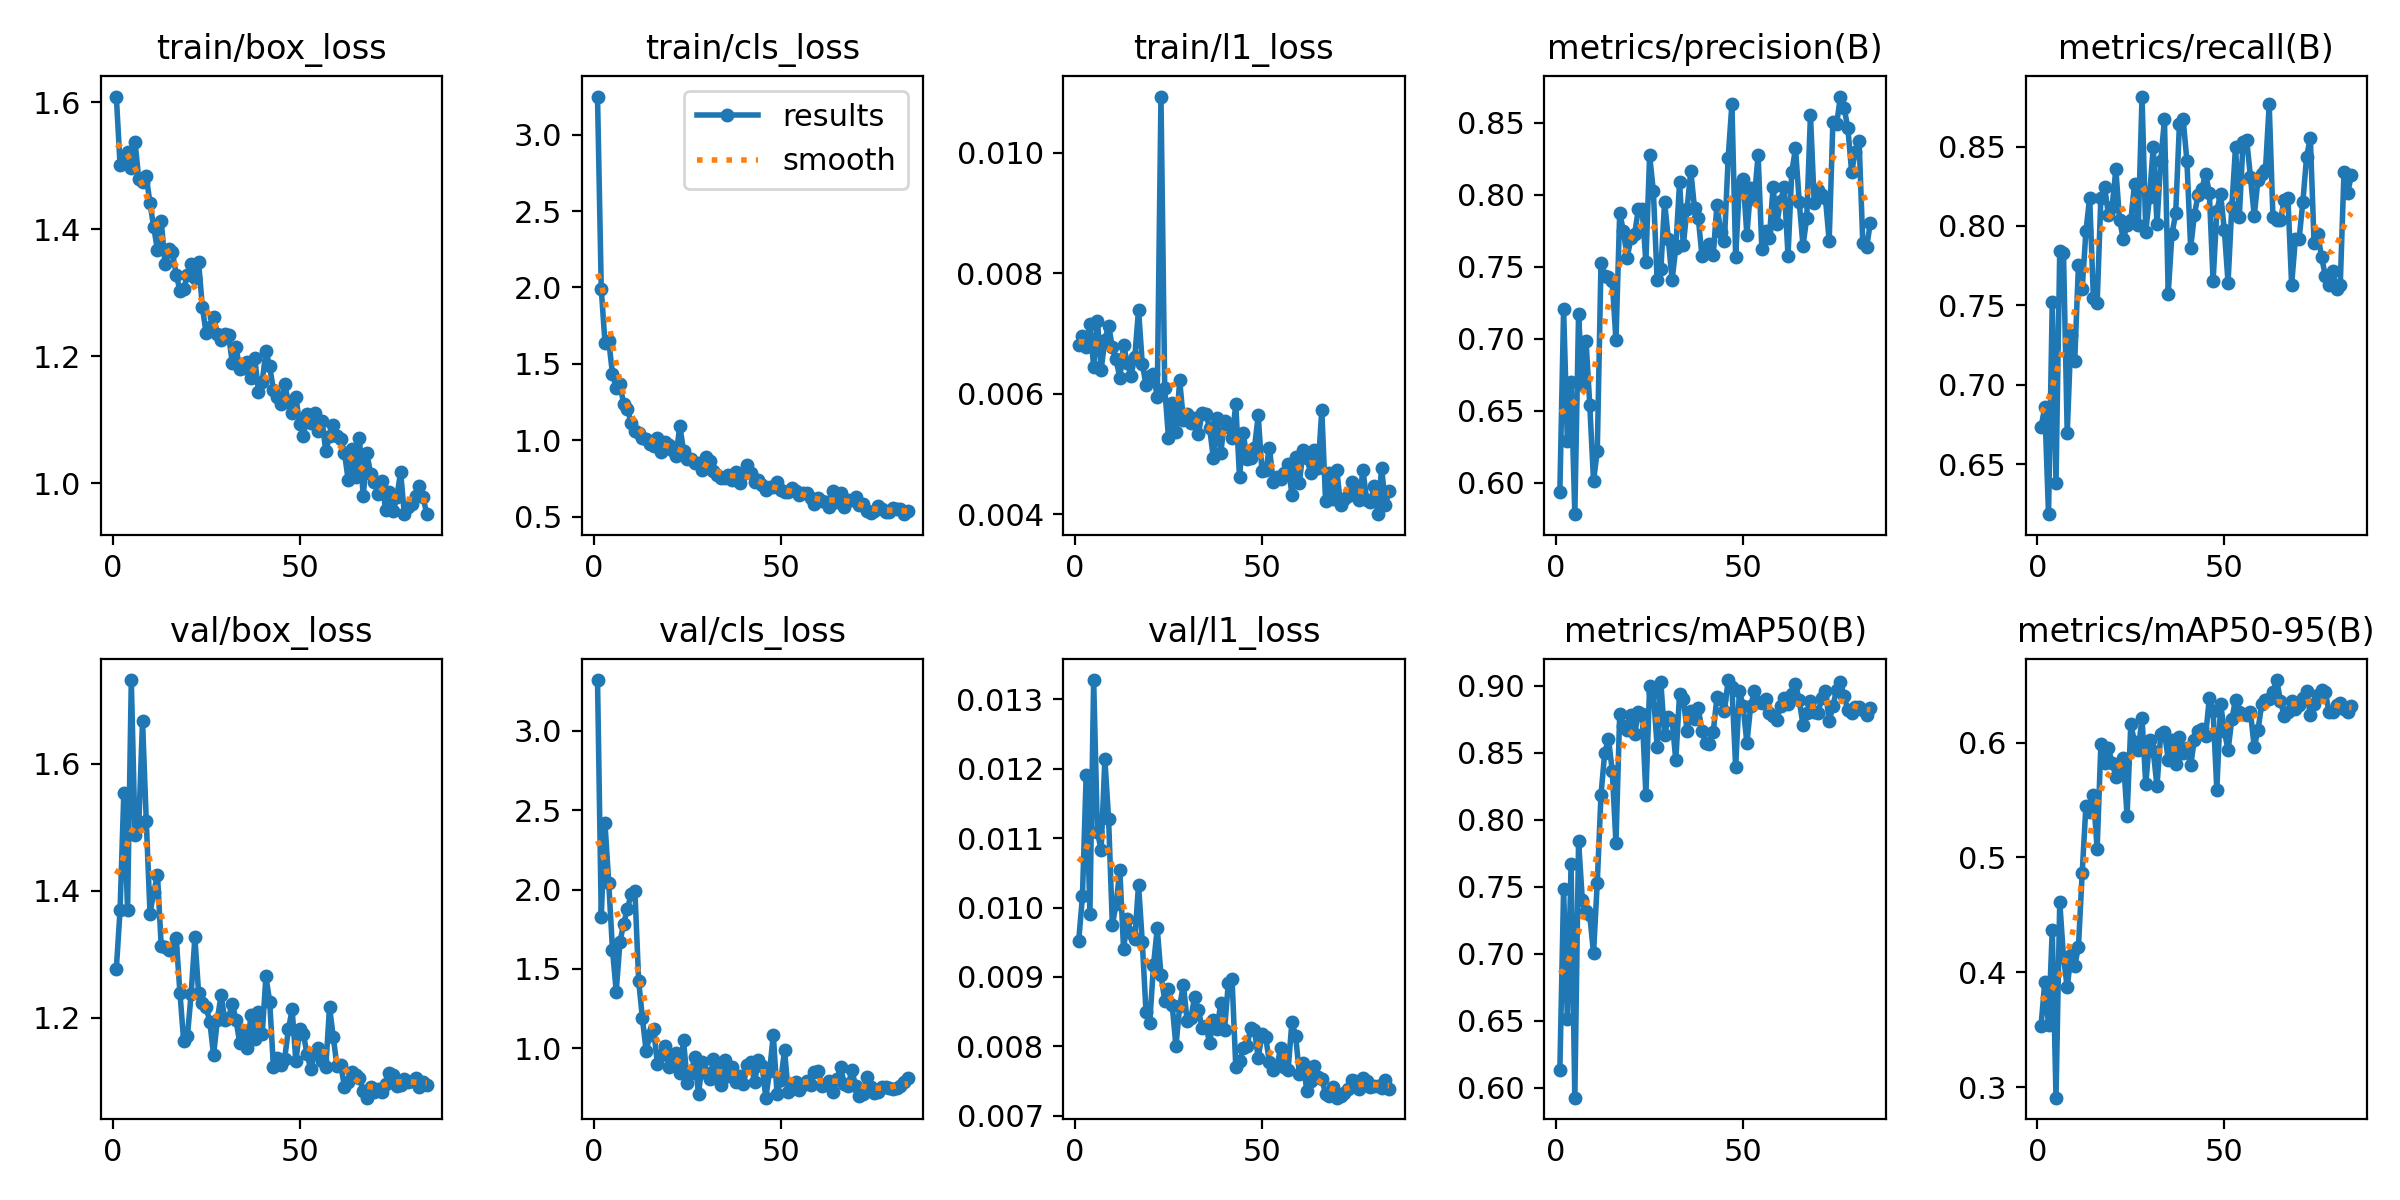

In [ ]:
from IPython.display import display, Image as DisplayImage

curve_path = run_dir / "results.png"
if curve_path.is_file():
    display(DisplayImage(filename=str(curve_path), width=1200))
else:
    print("Not found:", curve_path)

### Optional validation image comparison
Inspect missed fish, extra detections, and box alignment. The original image outputs were cleared.

In [ ]:
for filename in ["val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    path = run_dir / filename
    if path.is_file():
        print(filename)
        display(DisplayImage(filename=str(path), width=1200))

### Optional held-out test evaluation
Enable `RUN_TEST_EVALUATION` in configuration to evaluate the selected checkpoint. Keep test results separate from training-time validation and avoid repeatedly using test outcomes to tune the model. This cell does not train.

In [ ]:
if RUN_TEST_EVALUATION:
    from ultralytics import YOLO
    from datetime import datetime
    if not WEIGHTS.is_file():
        raise FileNotFoundError(WEIGHTS)
    test_results = YOLO(str(WEIGHTS)).val(
        data=str(working_path / "data.yaml"),
        split="test",
        imgsz=IMAGE_SIZE,
        batch=8,
        device=0 if torch.cuda.is_available() else "cpu",
        plots=True,
        project=str(project_path),
        name="detection_test_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"),
    )
else:
    print("Test evaluation skipped; recorded results are shown above.")

## 8. Video inspection
The supplied experiment uses GH010031 from BoostCompTrack, separate from the detection-training dataset. Change `VIDEO_DRIVE` to select another recording such as cage 07. A different filename alone does not prove independent recording provenance. AVI and MP4 inputs depend on available decoding support.

In [ ]:
from pathlib import Path
import cv2

video_path = VIDEO_DRIVE

assert video_path.is_file(), f"Video not found: {video_path}"

cap = cv2.VideoCapture(str(video_path))

try:
    if not cap.isOpened():
        raise RuntimeError("OpenCV could not open the video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Resolution: {width} × {height} pixels")
    print(f"Frame rate: {fps:.2f} FPS")
    print(f"Total frames: {frame_count}")

    if fps > 0:
        duration = frame_count / fps
        print(f"Duration: {duration:.1f} seconds ({duration / 60:.2f} minutes)")
    else:
        print("Duration unavailable: frame rate could not be read.")

    readable, frame = cap.read()
    print("First frame readable:", readable)

finally:
    cap.release()

## 9. Qualitative video detection
Process consecutive frames and save boxes with confidence scores. No IDs are assigned in this mode.

Saved MP4 previews preserve the source aspect ratio (rounded to even output dimensions) and reported FPS, without audio. This section is qualitative; no tracking ground truth or tracking accuracy metrics are computed.

In [ ]:
from pathlib import Path
from datetime import datetime
import shutil
import cv2
import torch
from ultralytics import YOLO

import math

device = 0 if torch.cuda.is_available() else "cpu"
for path in [VIDEO_DRIVE, WEIGHTS]:
    if not path.is_file():
        raise FileNotFoundError(path)
local_dir = Path("/content/salmon_detection_video")
local_dir.mkdir(parents=True, exist_ok=True)
local_video = local_dir / VIDEO_DRIVE.name
# Always refresh the local copy when this cell runs.
shutil.copy2(VIDEO_DRIVE, local_video)
detector = YOLO(str(WEIGHTS))

output_path = Path("/content/salmon_detection_preview.mp4")
cap = cv2.VideoCapture(str(local_video))
writer = None
processed = 0

try:
    if not cap.isOpened():
        raise RuntimeError("Could not open the video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not math.isfinite(fps) or fps <= 0:
        raise RuntimeError("Could not read the frame rate.")

    # Save a preview using the configured width.
    source_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    source_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if source_width <= 0 or source_height <= 0:
        raise RuntimeError("Could not read video dimensions.")
    output_width = source_width if OUTPUT_WIDTH is None else min(OUTPUT_WIDTH, source_width)
    output_height = round(source_height * output_width / source_width)
    output_size = (max(2, output_width // 2 * 2), max(2, output_height // 2 * 2))

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        output_size,
    )
    if not writer.isOpened():
        raise RuntimeError("Could not create the output video.")

    for _ in range(max(1, round(fps * SECONDS))):
        readable, frame = cap.read()
        if not readable:
            break

        prediction = detector.predict(
            source=frame,
            imgsz=IMAGE_SIZE,
            conf=DETECTION_CONF,
            device=device,
            verbose=False,
        )[0]

        annotated = prediction.plot(line_width=2, font_size=12)
        preview_frame = cv2.resize(
            annotated, output_size, interpolation=cv2.INTER_AREA
        )
        writer.write(preview_frame)

        processed += 1
        if processed % 60 == 0:
            print(f"Processed {processed} frames")

finally:
    cap.release()
    if writer is not None:
        writer.release()

if processed == 0:
    raise RuntimeError("No frames were processed.")

# Save the preview to Drive with a unique filename.
preview_folder = project_path / "video_previews"
preview_folder.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
saved_preview = preview_folder / f"{VIDEO_DRIVE.stem}_detection_{SECONDS}s_{timestamp}.mp4"
shutil.copy2(output_path, saved_preview)

print("Preview saved to:", saved_preview)

## 10. ByteTrack video tracking
A fresh model resets the tracker for each video. `persist=True` connects consecutive frames. A lower detection threshold retains candidates for tracking association; this is not a controlled comparison of detector thresholds. Colors are deterministic per ID but can repeat.

Saved MP4 previews preserve the source aspect ratio (rounded to even output dimensions) and reported FPS, without audio. This section is qualitative; no tracking ground truth or tracking accuracy metrics are computed.

In [ ]:
from pathlib import Path
from datetime import datetime
import shutil
import cv2
import torch
from ultralytics import YOLO

import math

device = 0 if torch.cuda.is_available() else "cpu"
for path in [VIDEO_DRIVE, WEIGHTS]:
    if not path.is_file():
        raise FileNotFoundError(path)
local_dir = Path("/content/salmon_detection_video")
local_dir.mkdir(parents=True, exist_ok=True)
local_video = local_dir / VIDEO_DRIVE.name
# Always refresh the local copy when this cell runs.
shutil.copy2(VIDEO_DRIVE, local_video)
tracking_model = YOLO(str(WEIGHTS))

output_path = Path("/content/salmon_bytetrack_preview.mp4")
cap = cv2.VideoCapture(str(local_video))
writer = None
processed = 0

try:
    if not cap.isOpened():
        raise RuntimeError("Could not open the video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not math.isfinite(fps) or fps <= 0:
        raise RuntimeError("Could not read the frame rate.")

    source_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    source_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if source_width <= 0 or source_height <= 0:
        raise RuntimeError("Could not read video dimensions.")
    output_width = source_width if OUTPUT_WIDTH is None else min(OUTPUT_WIDTH, source_width)
    output_height = round(source_height * output_width / source_width)
    output_size = (max(2, output_width // 2 * 2), max(2, output_height // 2 * 2))

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        output_size,
    )
    if not writer.isOpened():
        raise RuntimeError("Could not create the output video.")

    for _ in range(max(1, round(fps * SECONDS))):
        readable, frame = cap.read()
        if not readable:
            break

        result = tracking_model.track(
            source=frame,
            persist=True,
            tracker="bytetrack.yaml",
            imgsz=IMAGE_SIZE,
            conf=TRACKING_CONF,
            device=device,
            verbose=False,
        )[0]

        # Draw tracked boxes and IDs on the output-sized preview.
        preview = cv2.resize(
            frame, output_size, interpolation=cv2.INTER_AREA
        )
        scale_x = output_size[0] / frame.shape[1]
        scale_y = output_size[1] / frame.shape[0]

        if result.boxes is not None and result.boxes.id is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            track_ids = result.boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                x1, y1, x2, y2 = box
                x1, x2 = int(x1 * scale_x), int(x2 * scale_x)
                y1, y2 = int(y1 * scale_y), int(y2 * scale_y)

                # Consistent color for each track ID.
                color = (
                    50 + (track_id * 37) % 206,
                    50 + (track_id * 67) % 206,
                    50 + (track_id * 97) % 206,
                )

                cv2.rectangle(preview, (x1, y1), (x2, y2), color, 2)
                cv2.putText(
                    preview,
                    f"ID {track_id}",
                    (x1, max(y1 - 8, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.65,
                    color,
                    2,
                    cv2.LINE_AA,
                )

        writer.write(preview)
        processed += 1

        if processed % 60 == 0:
            print(f"Processed {processed} frames")

finally:
    cap.release()
    if writer is not None:
        writer.release()

if processed == 0:
    raise RuntimeError("No frames were processed.")

preview_folder = project_path / "video_previews"
preview_folder.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
saved_preview = preview_folder / f"{VIDEO_DRIVE.stem}_bytetrack_{SECONDS}s_{timestamp}.mp4"
shutil.copy2(output_path, saved_preview)

print("Tracking preview saved to:", saved_preview)

## 11. Findings and limitations

The original video cells processed 300 frames (about ten seconds) in both modes. The project author observed more stable tracking when fish were separated and ID switches or new IDs during overlaps. These observations are qualitative, not an IDF1 or HOTA benchmark.

- Track IDs are temporary associations, not permanent biological identities.
- Maximum track ID is not the number of unique fish, and visible detections are not a cage population estimate.
- Camera motion, low visibility, small fish, and incomplete annotations can affect the results.
- Recorded validation and test metrics describe the Healthy and Loser Salmon dataset; they are not metrics for the BoostCompTrack videos.
- Cage 07 was subsequently reported as a qualitative project experiment, but its outputs are not present in this original notebook. Selecting that video here enables a new run, not reproduction of a saved benchmark.
- This model does not measure fish health, physical size, weight, appetite, or welfare.

## Next steps
Evaluate separate recordings with reviewed labels; annotate consecutive-frame identities for tracking evaluation; document errors by fish size, overlap, and visibility; and extract movement measurements only after assessing tracking quality.

## References
- [Healthy and Loser Salmon dataset](https://data.mendeley.com/datasets/rvrt4zs969/1)
- [BoostCompTrack data](https://zenodo.org/records/16880877)
- [Ultralytics documentation](https://docs.ultralytics.com/)
- [ByteTrack implementation](https://github.com/ifzhang/ByteTrack)